# Ad Ease Website Analytics: Multi-Language Page View Forecasting

## Strategic Context
Ad Ease optimizes ad placement by forecasting Wikipedia page views across languages. Reliable forecasts help clients improve click outcomes at lower spend and support budget planning by market.

## Problem Definition
Build a robust, business-ready forecasting pipeline for aggregated daily page views by language, then compare baseline and advanced time-series models to identify the most reliable approach per language.

## Confidentiality
No client-identifiable entities are disclosed. Any stakeholder labels in this notebook are anonymized.

## Notebook Roadmap
1. Data loading and structural quality checks
2. Preprocessing and language-level aggregation
3. EDA (univariate, bivariate, multivariate, outliers, skewness)
4. Stationarity, decomposition, differencing, ACF/PACF
5. Train/validation/test setup for time series
6. Baselines and tuned statistical models (ARIMA/SARIMAX)
7. Optional Prophet benchmark (if installed)
8. Model comparison, residual diagnostics, and forecast outputs
9. Executive summary, recommendations, risks, and monitoring plan

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tools.sm_exceptions import ValueWarning
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Explicitly suppress statsmodels frequency inference warnings in notebook output
warnings.filterwarnings('ignore', category=ValueWarning)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Resolve file paths so this notebook runs regardless of current working directory
candidate_train_paths = [
    Path('../data/train_1.csv'),
    Path('data/train_1.csv'),
    Path('../../TimeSeries/data/train_1.csv')
]

TRAIN_PATH = next((p for p in candidate_train_paths if p.exists()), None)
if TRAIN_PATH is None:
    raise FileNotFoundError('Could not locate train_1.csv in expected paths.')

candidate_exog_paths = [
    Path('../data/Exog_Campaign_eng.csv'),
    Path('../data/exog_campaign_eng.csv'),
    Path('../data/Exog_Campaign_eng.xlsx'),
    Path('data/Exog_Campaign_eng.csv')
]

EXOG_PATH = next((p for p in candidate_exog_paths if p.exists()), None)

df_raw = pd.read_csv(TRAIN_PATH)
print(f'Train file loaded: {TRAIN_PATH}')
print(f'Shape: {df_raw.shape}')
print('Exogenous campaign file found:' if EXOG_PATH else 'Exogenous campaign file not found in expected paths.')
if EXOG_PATH:
    print(f'Exog file loaded from: {EXOG_PATH}')

display(df_raw.head(2))

Train file loaded: ..\data\train_1.csv
Shape: (145063, 551)
Exogenous campaign file not found in expected paths.


,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,2015-07-11,2015-07-12,2015-07-13,2015-07-14,2015-07-15,2015-07-16,2015-07-17,2015-07-18,2015-07-19,2015-07-20,2015-07-21,2015-07-22,2015-07-23,2015-07-24,2015-07-25,2015-07-26,2015-07-27,2015-07-28,2015-07-29,2015-07-30,2015-07-31,2015-08-01,2015-08-02,2015-08-03,2015-08-04,2015-08-05,2015-08-06,2015-08-07,2015-08-08,2015-08-09,2015-08-10,2015-08-11,2015-08-12,2015-08-13,2015-08-14,2015-08-15,2015-08-16,2015-08-17,2015-08-18,2015-08-19,2015-08-20,2015-08-21,2015-08-22,2015-08-23,2015-08-24,2015-08-25,2015-08-26,2015-08-27,2015-08-28,2015-08-29,2015-08-30,2015-08-31,2015-09-01,2015-09-02,2015-09-03,2015-09-04,2015-09-05,2015-09-06,2015-09-07,2015-09-08,2015-09-09,2015-09-10,2015-09-11,2015-09-12,2015-09-13,2015-09-14,2015-09-15,2015-09-16,2015-09-17,2015-09-18,2015-09-19,2015-09-20,2015-09-21,2015-09-22,2015-09-23,2015-09-24,2015-09-25,2015-09-26,2015-09-27,2015-09-28,2015-09-29,2015-09-30,2015-10-01,2015-10-02,2015-10-03,2015-10-04,2015-10-05,2015-10-06,2015-10-07,...,2016-09-23,2016-09-24,2016-09-25,2016-09-26,2016-09-27,2016-09-28,2016-09-29,2016-09-30,2016-10-01,2016-10-02,2016-10-03,2016-10-04,2016-10-05,2016-10-06,2016-10-07,2016-10-08,2016-10-09,2016-10-10,2016-10-11,2016-10-12,2016-10-13,2016-10-14,2016-10-15,2016-10-16,2016-10-17,2016-10-18,2016-10-19,2016-10-20,2016-10-21,2016-10-22,2016-10-23,2016-10-24,2016-10-25,2016-10-26,2016-10-27,2016-10-28,2016-10-29,2016-10-30,2016-10-31,2016-11-01,2016-11-02,2016-11-03,2016-11-04,2016-11-05,2016-11-06,2016-11-07,2016-11-08,2016-11-09,2016-11-10,2016-11-11,2016-11-12,2016-11-13,2016-11-14,2016-11-15,2016-11-16,2016-11-17,2016-11-18,2016-11-19,2016-11-20,2016-11-21,2016-11-22,2016-11-23,2016-11-24,2016-11-25,2016-11-26,2016-11-27,2016-11-28,2016-11-29,2016-11-30,2016-12-01,2016-12-02,2016-12-03,2016-12-04,2016-12-05,2016-12-06,2016-12-07,2016-12-08,2016-12-09,2016-12-10,2016-12-11,2016-12-12,2016-12-13,2016-12-14,2016-12-15,2016-12-16,2016-12-17,2016-12-18,2016-12-19,2016-12-20,2016-12-21,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,24.0,19.0,10.0,14.0,15.0,8.0,16.0,8.0,8.0,16.0,7.0,11.0,10.0,20.0,18.0,15.0,14.0,49.0,10.0,16.0,18.0,8.0,5.0,9.0,7.0,13.0,9.0,7.0,4.0,11.0,10.0,5.0,9.0,9.0,9.0,9.0,13.0,4.0,15.0,25.0,9.0,5.0,6.0,20.0,3.0,14.0,46.0,5.0,5.0,13.0,4.0,9.0,10.0,9.0,11.0,11.0,11.0,9.0,15.0,5.0,10.0,7.0,4.0,8.0,9.0,10.0,6.0,13.0,16.0,6.0,24.0,9.0,11.0,12.0,8.0,14.0,6.0,6.0,11.0,14.0,6.0,10.0,20.0,7.0,15.0,8.0,15.0,5.0,8.0,8.0,...,10.0,13.0,44.0,17.0,13.0,72.0,40.0,19.0,14.0,13.0,12.0,14.0,10.0,26.0,13.0,22.0,14.0,23.0,12.0,8.0,50.0,13.0,10.0,16.0,14.0,10.0,24.0,10.0,20.0,10.0,26.0,25.0,16.0,19.0,20.0,12.0,19.0,50.0,16.0,30.0,18.0,25.0,14.0,20.0,8.0,67.0,13.0,41.0,10.0,21.0,13.0,8.0,15.0,14.0,12.0,6.0,11.0,10.0,42.0,21.0,24.0,14.0,11.0,204.0,14.0,45.0,33.0,28.0,18.0,14.0,47.0,15.0,14.0,18.0,20.0,14.0,16.0,14.0,20.0,60.0,22.0,15.0,17.0,19.0,18.0,21.0,21.0,47.0,65.0,17.0,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,4.0,41.0,65.0,57.0,38.0,20.0,62.0,44.0,15.0,10.0,47.0,24.0,17.0,22.0,9.0,39.0,13.0,11.0,12.0,21.0,19.0,9.0,15.0,33.0,8.0,8.0,7.0,13.0,2.0,23.0,12.0,27.0,27.0,36.0,23.0,58.0,80.0,60.0,69.0,42.0,161.0,94.0,77.0,78.0,20.0,24.0,13.0,14.0,26.0,8.0,82.0,22.0,11.0,81.0,37.0,9.0,40.0,47.0,18.0,23.0,6.0,2.0,7.0,16.0,10.0,34.0,14.0,31.0,20.0,23.0,14.0,16.0,34.0,15.0,30.0,13.0,30.0,15.0,25.0,17.0,8.0,12.0,17.0,10.0,21.0,18.0,30.0,13.0,7.0,15.0,...,26.0,20.0,27.0,35.0,20.0,31.0,24.0,24.0,94.0,18.0,20.0,18.0,16.0,38.0,54.0,29.0,49.0,25.0,72.0,144.0,36.0,97.0,179.0,29.0,12.0,21.0,42.0,53.0,41.0,19.0,25.0,19.0,15.0,21.0,21.0,27.0,33.0,15.0,24.0,13.0,11.0,14.0,26.0,11.0,21.0,14.0,14.0,54.0,5.0,10.0,12.0,11.0,14.0,28.0,23.0,20.0,9.

In [3]:
# Schema and data quality checks
print('Column count:', df_raw.shape[1])
print('Row count:', df_raw.shape[0])
print('First 5 columns:', df_raw.columns[:5].tolist())
print('Last 5 columns:', df_raw.columns[-5:].tolist())

missing_counts = df_raw.isna().sum().sort_values(ascending=False)
missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': (missing_counts / len(df_raw) * 100).round(4)
})

print('Top missingness columns:')
display(missing_summary.head(10))

dup_rows = df_raw.duplicated().sum()
dup_pages = df_raw.duplicated(subset=['Page']).sum()
print(f'Duplicate full rows: {dup_rows}')
print(f'Duplicate Page entries: {dup_pages}')

Column count: 551
Row count: 145063
First 5 columns: ['Page', '2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04']
Last 5 columns: ['2016-12-27', '2016-12-28', '2016-12-29', '2016-12-30', '2016-12-31']
Top missingness columns:


,missing_count,missing_pct
2015-07-02,20816,14.3496
2015-07-01,20740,14.2972
2015-07-07,20664,14.2448
2015-07-05,20659,14.2414
2015-07-04,20654,14.2380
2015-07-03,20544,14.1621
2015-07-11,20525,14.1490
2015-07-12,20485,14.1215
2015-07-06,20483,14.1201
2015-07-13,20399,14.0622


Duplicate full rows: 0
Duplicate Page entries: 0


In [4]:
# Parse language and access metadata from page names
df = df_raw.copy()

meta_pattern = r'_(?P<lang>[a-z\-]+)\.wikipedia\.org_(?P<access>[^_]+-[^_]+)_(?P<agent>[^_]+)$'
meta = df['Page'].str.extract(meta_pattern)

df['language'] = meta['lang'].fillna('unknown')
df['access_type'] = meta['access'].fillna('unknown_access')
df['access_agent'] = meta['agent'].fillna('unknown_agent')

# Identify all date columns in wide format
date_cols = [c for c in df.columns if re.match(r'^\d{4}-\d{2}-\d{2}$', str(c))]
print('Date columns detected:', len(date_cols))

for c in date_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print('Languages detected:', df['language'].nunique())
display(df[['Page', 'language', 'access_type', 'access_agent']].head(3))

Date columns detected: 550
Languages detected: 8


,Page,language,access_type,access_agent
0,2NE1_zh.wikipedia.org_all-access_spider,zh,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,zh,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,zh,all-access,spider


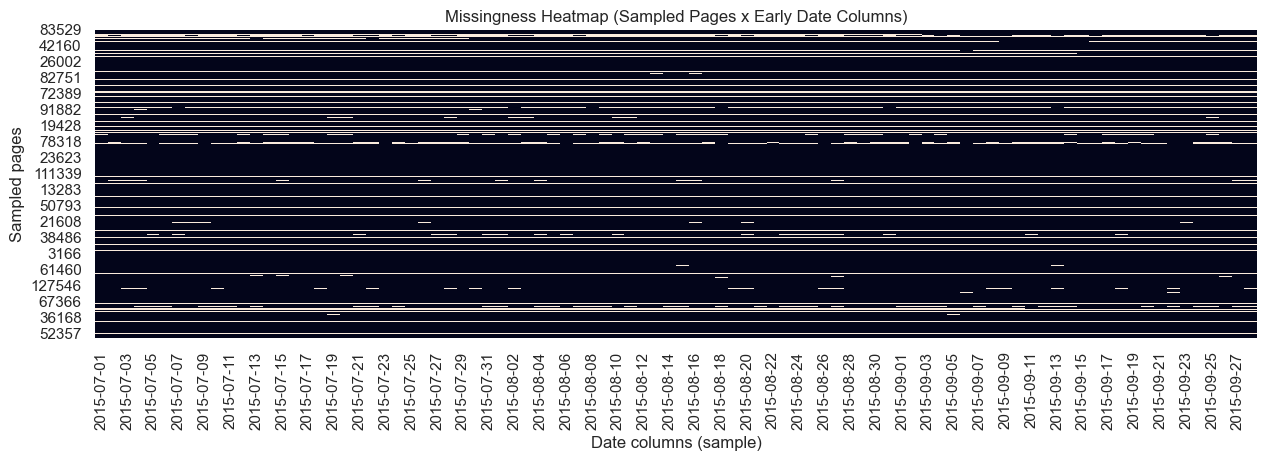

Median row-level missing share: 0.0
95th percentile row-level missing share: 0.6527


In [5]:
# Missingness pattern across a sampled set of pages and dates
sample_rows = min(500, len(df))
sample_cols = min(90, len(date_cols))
sampled_dates = date_cols[:sample_cols]
sampled_idx = np.random.RandomState(RANDOM_STATE).choice(df.index, size=sample_rows, replace=False)
null_matrix = df.loc[sampled_idx, sampled_dates].isna().astype(int)

plt.figure(figsize=(15, 4))
sns.heatmap(null_matrix, cbar=False)
plt.title('Missingness Heatmap (Sampled Pages x Early Date Columns)')
plt.xlabel('Date columns (sample)')
plt.ylabel('Sampled pages')
plt.show()

row_nan_share = df[date_cols].isna().mean(axis=1)
print('Median row-level missing share:', round(float(row_nan_share.median()), 4))
print('95th percentile row-level missing share:', round(float(row_nan_share.quantile(0.95)), 4))

In [6]:
# Aggregate to language-level daily views in long-format friendly structure
df_grouped = df.groupby('language')[date_cols].sum(min_count=1).fillna(0)
lang_daily = df_grouped.T
lang_daily.index = pd.to_datetime(lang_daily.index)
lang_daily = lang_daily.sort_index().asfreq('D')

# Optional smoothing helper columns for EDA
lang_rolling_7 = lang_daily.rolling(window=7, min_periods=1).mean()
lang_rolling_30 = lang_daily.rolling(window=30, min_periods=1).mean()

long_df = lang_daily.reset_index().melt(id_vars='index', var_name='language', value_name='views')
long_df = long_df.rename(columns={'index': 'date'})

language_volume = long_df.groupby('language', as_index=False)['views'].sum().sort_values('views', ascending=False)
top_languages = language_volume['language'].head(8).tolist()

print('Language-level daily matrix shape:', lang_daily.shape)
display(language_volume.head(15))

Language-level daily matrix shape: (550, 8)


,language,views
1,en,4.143970e+10
6,unknown,2.928629e+10
2,es,7.318862e+09
4,ja,6.973910e+09
0,de,6.857948e+09
5,ru,5.528652e+09
3,fr,4.869739e+09
7,zh,2.224114e+09


## Exploratory Data Analysis
The next cells cover univariate, bivariate, and multivariate behavior, plus outlier and skewness diagnostics.

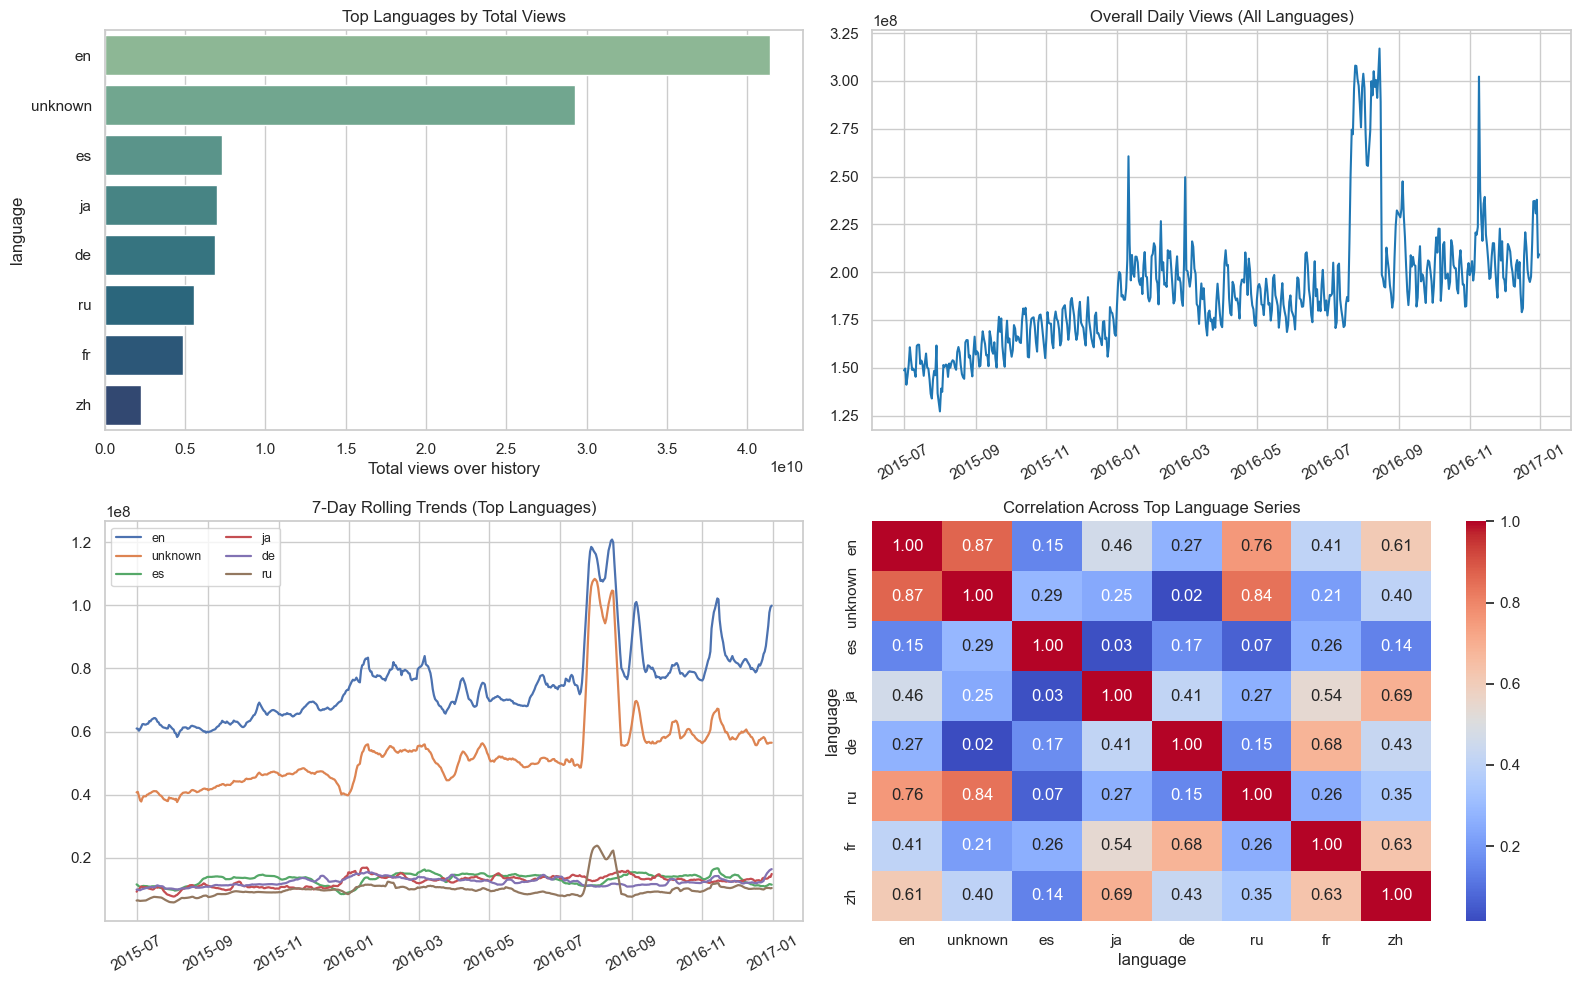

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(data=language_volume.head(12), x='views', y='language', ax=axes[0, 0], palette='crest')
axes[0, 0].set_title('Top Languages by Total Views')
axes[0, 0].set_xlabel('Total views over history')

total_daily = lang_daily.sum(axis=1)
axes[0, 1].plot(total_daily.index, total_daily.values, color='#1f77b4')
axes[0, 1].set_title('Overall Daily Views (All Languages)')
axes[0, 1].tick_params(axis='x', rotation=30)

for lang in top_languages[:6]:
    axes[1, 0].plot(lang_rolling_7.index, lang_rolling_7[lang], label=lang, linewidth=1.6)
axes[1, 0].set_title('7-Day Rolling Trends (Top Languages)')
axes[1, 0].legend(loc='upper left', ncol=2, fontsize=9)
axes[1, 0].tick_params(axis='x', rotation=30)

corr_top = lang_daily[top_languages[:8]].corr() if len(top_languages) >= 2 else pd.DataFrame()
if not corr_top.empty:
    sns.heatmap(corr_top, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1])
    axes[1, 1].set_title('Correlation Across Top Language Series')
else:
    axes[1, 1].text(0.5, 0.5, 'Not enough languages for correlation', ha='center', va='center')
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

,language,outlier_share
5,ru,0.069091
1,en,0.063636
6,unknown,0.050909
3,fr,0.047273
0,de,0.025455
4,ja,0.012727
7,zh,0.003636
2,es,0.001818


,language,skew_raw,skew_log1p
5,ru,3.000370,1.580929
6,unknown,2.263112,1.196918
1,en,1.574414,1.039583
0,de,1.093992,0.653026
4,ja,0.541323,-0.101316
3,fr,0.428835,-0.184960
7,zh,0.157173,-0.411243
2,es,0.076138,-0.347028


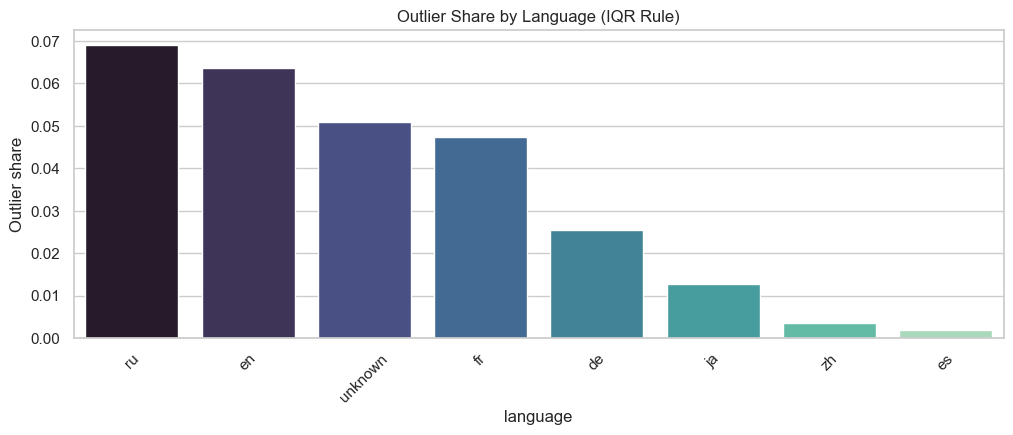

In [8]:
# Outlier and skewness analysis by language
outlier_records = []
skew_records = []

for lang in lang_daily.columns:
    s = lang_daily[lang].astype(float)
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_share = ((s < lower) | (s > upper)).mean()

    skew_raw = s.skew()
    skew_log = np.log1p(s).skew()

    outlier_records.append({'language': lang, 'outlier_share': outlier_share})
    skew_records.append({'language': lang, 'skew_raw': skew_raw, 'skew_log1p': skew_log})

outlier_df = pd.DataFrame(outlier_records).sort_values('outlier_share', ascending=False)
skew_df = pd.DataFrame(skew_records).sort_values('skew_raw', ascending=False)

display(outlier_df.head(10))
display(skew_df.head(10))

plt.figure(figsize=(12, 4))
sns.barplot(data=outlier_df.head(12), x='language', y='outlier_share', palette='mako')
plt.title('Outlier Share by Language (IQR Rule)')
plt.xticks(rotation=45)
plt.ylabel('Outlier share')
plt.show()

## Stationarity, Decomposition, Differencing, ACF, and PACF

In [9]:
def run_adf(series):
    s = pd.Series(series).dropna()
    if len(s) < 30:
        return {'adf_stat': np.nan, 'p_value': np.nan, 'n_obs': len(s), 'is_stationary_5pct': False}
    result = adfuller(s, autolag='AIC')
    return {
        'adf_stat': result[0],
        'p_value': result[1],
        'n_obs': result[3],
        'is_stationary_5pct': bool(result[1] < 0.05)
    }

adf_rows = []
for lang in lang_daily.columns:
    adf_out = run_adf(lang_daily[lang])
    adf_out['language'] = lang
    adf_rows.append(adf_out)

adf_df = pd.DataFrame(adf_rows).sort_values('p_value')
display(adf_df.head(15))
print('Share of languages stationary at 5% level (raw series):', round(adf_df['is_stationary_5pct'].mean(), 3))

,adf_stat,p_value,n_obs,is_stationary_5pct,language
5,-3.841414,0.002511,547,True,ru
2,-3.001005,0.034801,534,True,es
6,-2.977322,0.037067,535,True,unknown
4,-2.363707,0.152243,535,False,ja
3,-2.279667,0.178610,530,False,fr
0,-2.181550,0.213010,533,False,de
1,-2.082195,0.251734,535,False,en
7,-1.545159,0.511065,530,False,zh


Share of languages stationary at 5% level (raw series): 0.375


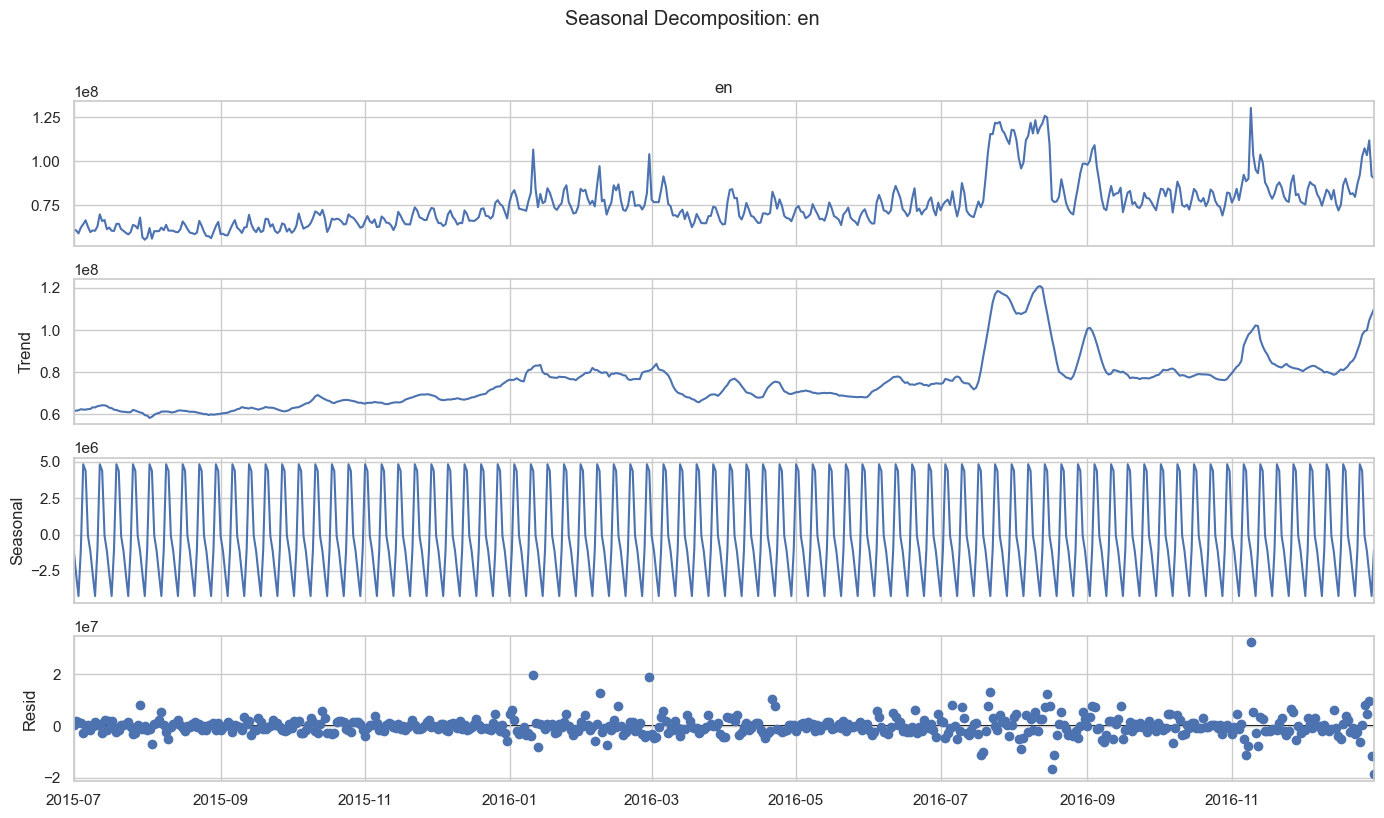

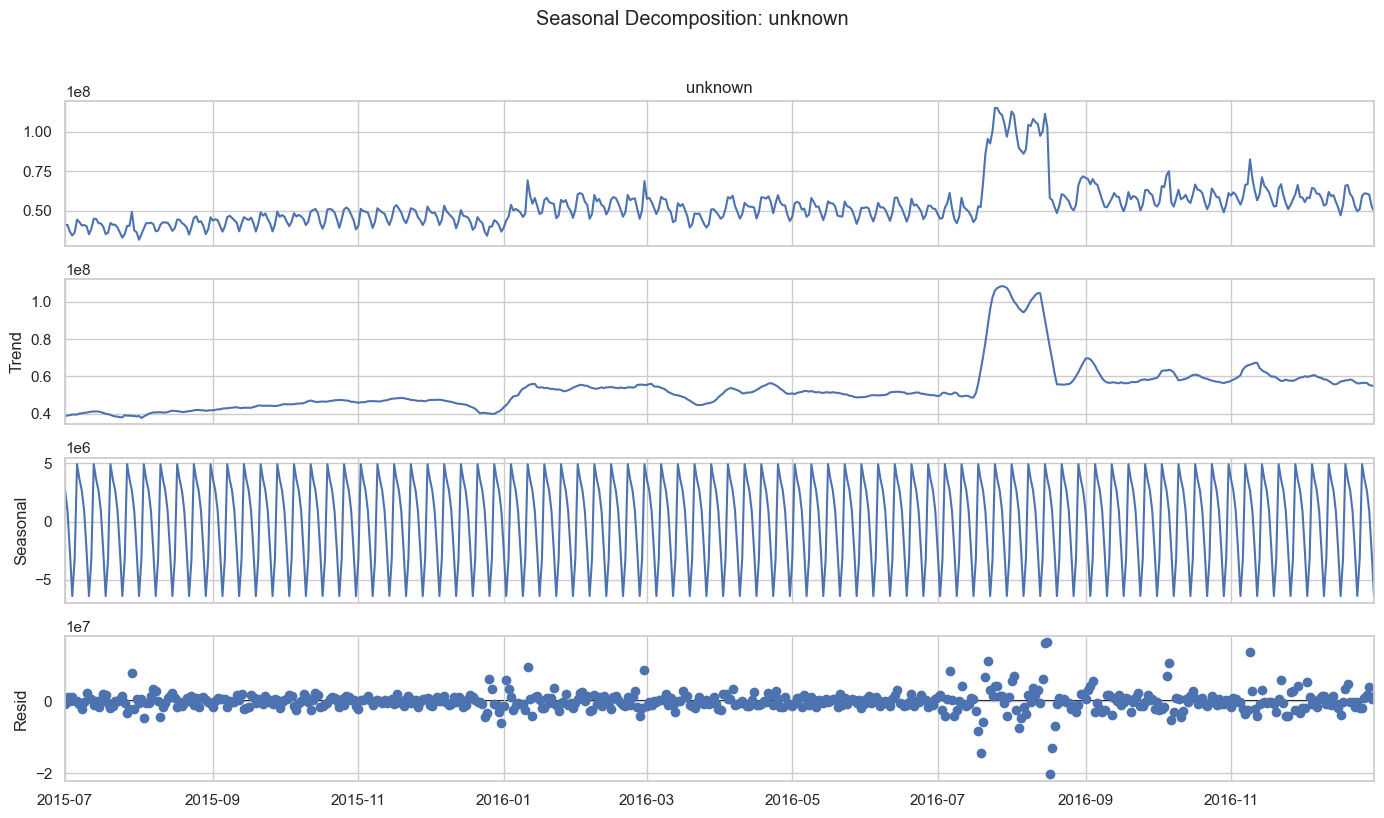

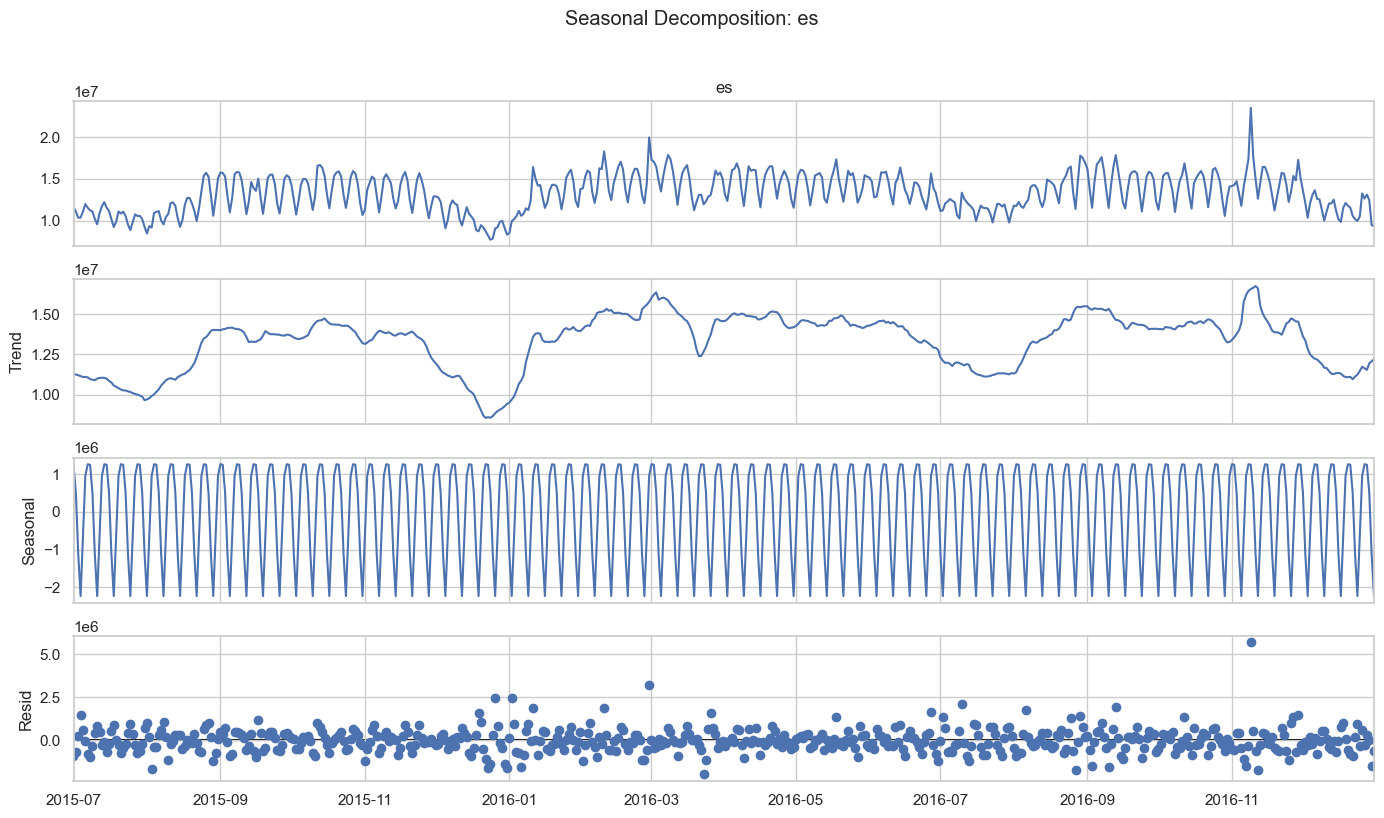

In [10]:
# Decomposition for the top 3 languages by total volume
decompose_langs = top_languages[:3]

for lang in decompose_langs:
    series = lang_daily[lang].asfreq('D')
    result = seasonal_decompose(series, model='additive', period=7, extrapolate_trend='freq')

    fig = result.plot()
    fig.set_size_inches(14, 8)
    plt.suptitle(f'Seasonal Decomposition: {lang}', y=1.02)
    plt.tight_layout()
    plt.show()

Focus language: en
ADF p-value (raw): 0.25173
ADF p-value (1st diff): 0.00000
ADF p-value (seasonal diff, lag=7): 0.00003


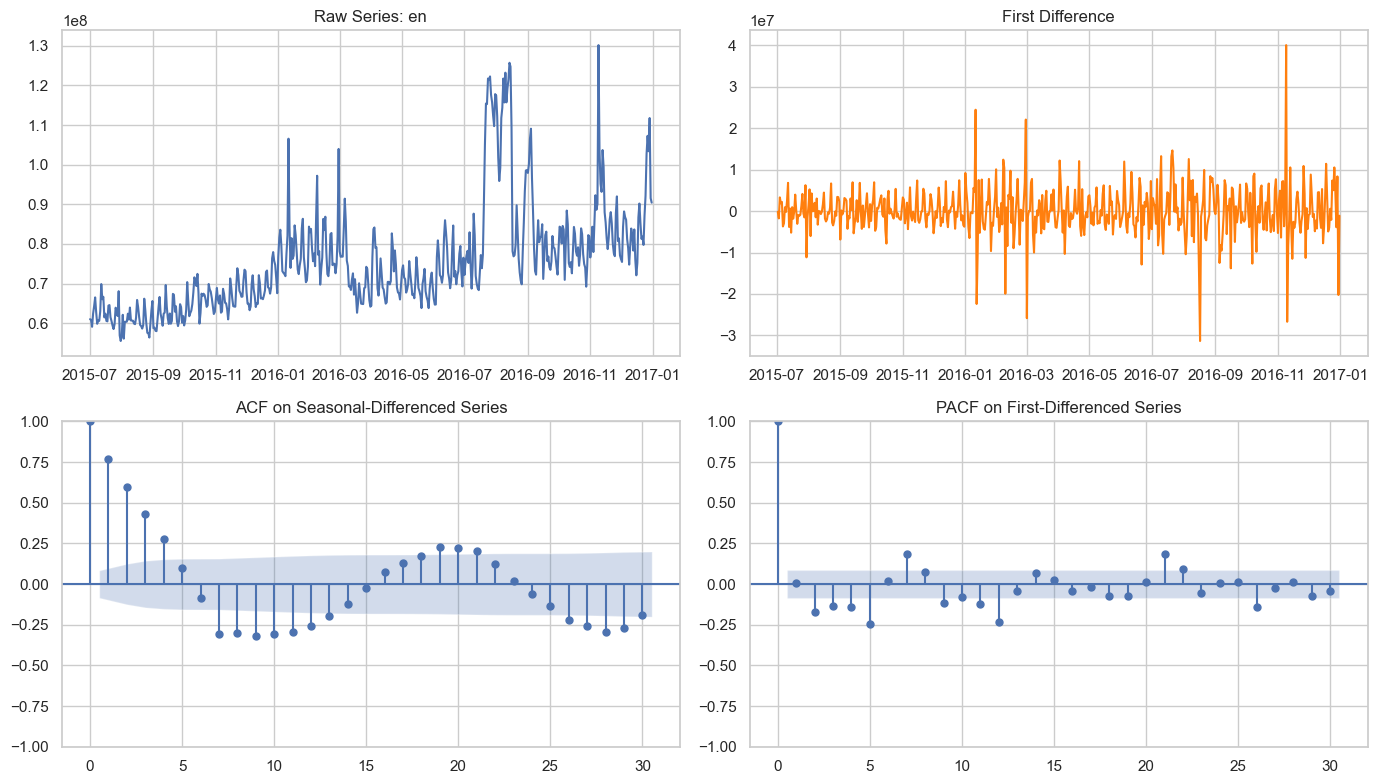

In [11]:
# ACF/PACF on differenced series for a focus language
focus_language = top_languages[0] if top_languages else lang_daily.columns[0]
focus_series = lang_daily[focus_language].copy()

diff1 = focus_series.diff().dropna()
seasonal_diff = focus_series.diff(7).dropna()

adf_raw = run_adf(focus_series)['p_value']
adf_diff1 = run_adf(diff1)['p_value']
adf_diff7 = run_adf(seasonal_diff)['p_value']

print(f'Focus language: {focus_language}')
print(f'ADF p-value (raw): {adf_raw:.5f}')
print(f'ADF p-value (1st diff): {adf_diff1:.5f}')
print(f'ADF p-value (seasonal diff, lag=7): {adf_diff7:.5f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(focus_series.index, focus_series.values)
axes[0, 0].set_title(f'Raw Series: {focus_language}')

axes[0, 1].plot(diff1.index, diff1.values, color='#ff7f0e')
axes[0, 1].set_title('First Difference')

plot_acf(seasonal_diff, lags=30, ax=axes[1, 0])
axes[1, 0].set_title('ACF on Seasonal-Differenced Series')

plot_pacf(diff1, lags=30, ax=axes[1, 1], method='ywm')
axes[1, 1].set_title('PACF on First-Differenced Series')

plt.tight_layout()
plt.show()

## Modeling Setup: Splits, Metrics, and Baselines
We use chronological split with holdout validation and test windows to avoid leakage.

In [12]:
def ensure_daily_freq(series):
    s = pd.Series(series).dropna().astype(float).copy()
    s.index = pd.DatetimeIndex(s.index)
    return s.asfreq('D')

def ts_split(series, val_size=60, test_size=60):
    s = ensure_daily_freq(series)
    if len(s) <= (val_size + test_size + 30):
        raise ValueError('Series too short for requested split sizes.')
    train = s.iloc[:-(val_size + test_size)].asfreq('D')
    val = s.iloc[-(val_size + test_size):-test_size].asfreq('D')
    test = s.iloc[-test_size:].asfreq('D')
    return train, val, test

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred))
    valid = denom != 0
    out = np.zeros_like(y_true, dtype=float)
    out[valid] = 2.0 * np.abs(y_pred[valid] - y_true[valid]) / denom[valid]
    return float(np.mean(out) * 100)

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': math.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'sMAPE': smape(y_true, y_pred)
    }

def naive_forecast(train, horizon):
    return np.repeat(train.iloc[-1], horizon)

def seasonal_naive_forecast(train, horizon, season_len=7):
    if len(train) < season_len:
        return naive_forecast(train, horizon)
    pattern = train.iloc[-season_len:].values
    reps = int(np.ceil(horizon / season_len))
    return np.tile(pattern, reps)[:horizon]

def moving_average_forecast(train, horizon, window=7):
    value = float(train.iloc[-window:].mean()) if len(train) >= window else float(train.mean())
    return np.repeat(value, horizon)

In [13]:
# Baseline benchmark across all languages
baseline_rows = []

for lang in lang_daily.columns:
    series = lang_daily[lang]
    try:
        train, val, test = ts_split(series, val_size=60, test_size=60)
    except ValueError:
        continue

    for model_name, pred_val, pred_test in [
        ('Naive', naive_forecast(train, len(val)), naive_forecast(pd.concat([train, val]), len(test))),
        ('SeasonalNaive_7', seasonal_naive_forecast(train, len(val), 7), seasonal_naive_forecast(pd.concat([train, val]), len(test), 7)),
        ('MovingAverage_7', moving_average_forecast(train, len(val), 7), moving_average_forecast(pd.concat([train, val]), len(test), 7))
    ]:
        val_metrics = regression_metrics(val.values, pred_val)
        test_metrics = regression_metrics(test.values, pred_test)

        baseline_rows.append({
            'language': lang,
            'model': model_name,
            'val_MAE': val_metrics['MAE'],
            'val_RMSE': val_metrics['RMSE'],
            'val_R2': val_metrics['R2'],
            'val_sMAPE': val_metrics['sMAPE'],
            'test_MAE': test_metrics['MAE'],
            'test_RMSE': test_metrics['RMSE'],
            'test_R2': test_metrics['R2'],
            'test_sMAPE': test_metrics['sMAPE']
        })

baseline_results = pd.DataFrame(baseline_rows)
display(baseline_results.sort_values(['language', 'val_RMSE']).head(20))

baseline_best = baseline_results.sort_values('val_RMSE').groupby('language', as_index=False).first()
display(baseline_best.head(15))

,language,model,val_MAE,val_RMSE,val_R2,val_sMAPE,test_MAE,test_RMSE,test_R2,test_sMAPE
1,de,SeasonalNaive_7,1.044610e+06,1.350131e+06,-0.734801,8.880619,1.289662e+06,1.974741e+06,-0.163847,9.500081
2,de,MovingAverage_7,1.086218e+06,1.463757e+06,-1.039086,9.101379,1.250064e+06,1.992696e+06,-0.185108,9.163234
0,de,Naive,1.324366e+06,1.664018e+06,-1.635200,11.284589,1.503639e+06,1.905302e+06,-0.083437,11.078940
5,en,MovingAverage_7,1.430048e+07,1.505198e+07,-3.352338,16.702642,1.080793e+07,1.472770e+07,-1.056013,12.612268
4,en,SeasonalNaive_7,1.500363e+07,1.793098e+07,-5.176513,17.136392,1.079519e+07,1.461450e+07,-1.024530,12.737508
3,en,Naive,2.071569e+07,2.145548e+07,-7.843246,23.262108,1.049657e+07,1.445132e+07,-0.979570,12.208008
7,es,SeasonalNaive_7,1.153090e+06,1.447362e+06,0.360220,7.471692,1.677730e+06,2.154497e+06,0.239638,12.422111
6,es,Naive,1.663483e+06,1.934284e+06,-0.142659,11.790457,2.133723e+06,2.649801e+06,-0.150151,15.916582
8,es,MovingAverage_7,1.608444e+06,2.121018e+06,-0.373931,11.318572,1.932533e+06,2.483846e+06,-0.010596,14.478320
10,fr,SeasonalNaive_7,6.908689e+05,9.680532e+05,-0.358535,7.516182,1.082770e+06,1.490025e+06,-0.747907,11.345002


,language,model,val_MAE,val_RMSE,val_R2,val_sMAPE,test_MAE,test_RMSE,test_R2,test_sMAPE
0,de,SeasonalNaive_7,1.044610e+06,1.350131e+06,-0.734801,8.880619,1.289662e+06,1.974741e+06,-0.163847,9.500081
1,en,MovingAverage_7,1.430048e+07,1.505198e+07,-3.352338,16.702642,1.080793e+07,1.472770e+07,-1.056013,12.612268
2,es,SeasonalNaive_7,1.153090e+06,1.447362e+06,0.360220,7.471692,1.677730e+06,2.154497e+06,0.239638,12.422111
3,fr,SeasonalNaive_7,6.908689e+05,9.680532e+05,-0.358535,7.516182,1.082770e+06,1.490025e+06,-0.747907,11.345002
4,ja,Naive,1.195295e+06,1.551150e+06,-0.071960,8.873690,2.011918e+06,2.632484e+06,-1.360986,15.871393
5,ru,Naive,9.455526e+05,1.315853e+06,-1.021221,10.041249,9.394439e+05,1.363121e+06,-0.666671,8.776396
6,unknown,MovingAverage_7,6.878802e+06,8.006070e+06,-1.091891,11.359965,5.243026e+06,6.789321e+06,-0.246347,8.826614
7,zh,SeasonalNaive_7,2.891664e+05,4.044059e+05,0.380032,6.143037,2.293596e+05,3.680245e+05,0.345988,4.930013


## Tuned Statistical Models: ARIMA and SARIMAX
- ARIMA: non-seasonal autoregressive approach
- SARIMAX: captures weekly seasonality and supports exogenous inputs

For English, campaign exogenous input is used only if the file is available.

In [14]:
# Prepare exogenous signal for English when available
campaign_series = None
if EXOG_PATH is not None:
    exog_df = pd.read_csv(EXOG_PATH)
    exog_df.columns = [str(c).strip() for c in exog_df.columns]

    date_col_candidates = [c for c in exog_df.columns if 'date' in c.lower()]
    flag_col_candidates = [c for c in exog_df.columns if c.lower() not in date_col_candidates]

    if date_col_candidates and flag_col_candidates:
        dcol = date_col_candidates[0]
        fcol = flag_col_candidates[0]
        exog_df[dcol] = pd.to_datetime(exog_df[dcol], errors='coerce')
        campaign_series = exog_df.set_index(dcol)[fcol].astype(float).sort_index()
        campaign_series = campaign_series.reindex(lang_daily.index).fillna(0.0)

print('Campaign exogenous series active:' if campaign_series is not None else 'Campaign exogenous series inactive (file unavailable or format mismatch).')

Campaign exogenous series inactive (file unavailable or format mismatch).


In [15]:
def fit_best_arima(train, val):
    best = None
    best_rmse = np.inf

    train = ensure_daily_freq(train)
    val = ensure_daily_freq(val)

    for p in [0, 1, 2]:
        for d in [0, 1]:
            for q in [0, 1, 2]:
                order = (p, d, q)
                try:
                    model = SARIMAX(train, order=order, seasonal_order=(0, 0, 0, 0),
                                    enforce_stationarity=False, enforce_invertibility=False)
                    fitted = model.fit(disp=False)
                    pred = fitted.forecast(steps=len(val))
                    rmse = math.sqrt(mean_squared_error(val, pred))
                    if rmse < best_rmse:
                        best_rmse = rmse
                        best = {'order': order, 'fitted': fitted, 'val_pred': pred}
                except Exception:
                    continue

    return best

def fit_sarimax(train, val, exog_train=None, exog_val=None):
    # Fixed weekly seasonal structure as a practical starting point
    train = ensure_daily_freq(train)
    val = ensure_daily_freq(val)
    model = SARIMAX(
        train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        exog=exog_train,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fitted = model.fit(disp=False)
    pred = fitted.forecast(steps=len(val), exog=exog_val)
    return fitted, pred

model_rows = []
model_store = {}

for lang in lang_daily.columns:
    series = ensure_daily_freq(lang_daily[lang])
    try:
        train, val, test = ts_split(series, val_size=60, test_size=60)
    except ValueError:
        continue

    best_arima = fit_best_arima(train, val)
    if best_arima is not None:
        train_val = ensure_daily_freq(pd.concat([train, val]))
        arima_refit = SARIMAX(train_val, order=best_arima['order'], seasonal_order=(0, 0, 0, 0),
                             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        arima_test_pred = arima_refit.forecast(steps=len(test))

        vm = regression_metrics(val.values, best_arima['val_pred'])
        tm = regression_metrics(test.values, arima_test_pred.values)
        model_rows.append({
            'language': lang, 'model': 'ARIMA_tuned', 'order': best_arima['order'],
            'val_RMSE': vm['RMSE'], 'val_MAE': vm['MAE'], 'val_R2': vm['R2'], 'val_sMAPE': vm['sMAPE'],
            'test_RMSE': tm['RMSE'], 'test_MAE': tm['MAE'], 'test_R2': tm['R2'], 'test_sMAPE': tm['sMAPE']
        })
        model_store[(lang, 'ARIMA_tuned')] = arima_refit

    try:
        use_exog = (lang == 'en') and (campaign_series is not None)
        exog_train = campaign_series.loc[train.index] if use_exog else None
        exog_val = campaign_series.loc[val.index] if use_exog else None
        exog_train_val = campaign_series.loc[ensure_daily_freq(pd.concat([train, val])).index] if use_exog else None
        exog_test = campaign_series.loc[test.index] if use_exog else None

        sarimax_fit, sarimax_val_pred = fit_sarimax(train, val, exog_train=exog_train, exog_val=exog_val)

        sarimax_refit = SARIMAX(
            ensure_daily_freq(pd.concat([train, val])),
            order=(1, 1, 1),
            seasonal_order=(1, 1, 1, 7),
            exog=exog_train_val,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        sarimax_test_pred = sarimax_refit.forecast(steps=len(test), exog=exog_test)

        vm = regression_metrics(val.values, sarimax_val_pred.values)
        tm = regression_metrics(test.values, sarimax_test_pred.values)

        label = 'SARIMAX_weekly_exog' if use_exog else 'SARIMA_weekly'
        model_rows.append({
            'language': lang, 'model': label, 'order': '(1,1,1)x(1,1,1,7)',
            'val_RMSE': vm['RMSE'], 'val_MAE': vm['MAE'], 'val_R2': vm['R2'], 'val_sMAPE': vm['sMAPE'],
            'test_RMSE': tm['RMSE'], 'test_MAE': tm['MAE'], 'test_R2': tm['R2'], 'test_sMAPE': tm['sMAPE']
        })
        model_store[(lang, label)] = sarimax_refit
    except Exception:
        pass

model_results = pd.DataFrame(model_rows)
display(model_results.sort_values(['language', 'val_RMSE']).head(30))

c:\Users\prath\Desktop\Prathamesh\Prathamesh\Learn\DSML\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\prath\Desktop\Prathamesh\Prathamesh\Learn\DSML\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\prath\Desktop\Prathamesh\Prathamesh\Learn\DSML\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\prath\Desktop\Prathamesh\Prathamesh\Learn\DSML\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.wa

,language,model,order,val_RMSE,val_MAE,val_R2,val_sMAPE,test_RMSE,test_MAE,test_R2,test_sMAPE
0,de,ARIMA_tuned,"(2, 1, 2)",1.091433e+06,7.346878e+05,-0.133684,5.985307,2.087948e+06,1.323999e+06,-0.301114,9.755496
1,de,SARIMA_weekly,"(1,1,1)x(1,1,1,7)",1.999362e+06,1.697916e+06,-2.804351,14.994343,1.943448e+06,1.588865e+06,-0.127254,11.654639
2,en,ARIMA_tuned,"(1, 1, 2)",1.687825e+07,1.610558e+07,-4.472555,18.602466,1.418499e+07,1.021441e+07,-0.907278,11.843813
3,en,SARIMA_weekly,"(1,1,1)x(1,1,1,7)",3.446287e+07,3.296072e+07,-21.815923,34.225436,1.615807e+07,1.268826e+07,-1.474769,15.244994
4,es,ARIMA_tuned,"(2, 1, 0)",1.812323e+06,1.558508e+06,-0.003108,11.033012,2.497843e+06,1.951867e+06,-0.022018,14.620436
5,es,SARIMA_weekly,"(1,1,1)x(1,1,1,7)",4.209881e+06,3.749001e+06,-4.412724,23.048616,3.576774e+06,3.286960e+06,-1.095615,29.919822
6,fr,ARIMA_tuned,"(2, 0, 1)",1.018737e+06,8.090800e+05,-0.504516,8.605381,1.482136e+06,1.289927e+06,-0.729446,12.971531
7,fr,SARIMA_weekly,"(1,1,1)x(1,1,1,7)",1.683568e+06,1.465010e+06,-3.108978,17.141365,1.048907e+06,6.868643e+05,0.133826,6.963683
9,ja,SARIMA_weekly,"(1,1,1)x(1,1,1,7)",1.156751e+06,8.035708e+05,0.403856,6.036929,3.383531e+06,2.687904e+06,-2.900340,22.744043
8,ja,ARIMA_tuned,"(1, 1, 0)",1.506750e+06,1.180122e+06,-0.011471,8.759175,2.545935e+06,1.913543e+06,-1.208293,14.995932


In [16]:
# Optional Prophet benchmark for top 3 languages if package is available
prophet_rows = []

try:
    from prophet import Prophet
    prophet_available = True
except Exception:
    prophet_available = False

if prophet_available:
    for lang in top_languages[:3]:
        series = lang_daily[lang].astype(float)
        try:
            train, val, test = ts_split(series, val_size=60, test_size=60)
        except ValueError:
            continue

        train_df = pd.DataFrame({'ds': train.index, 'y': train.values})
        m = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
        m.fit(train_df)

        future_val = pd.DataFrame({'ds': val.index})
        val_pred = m.predict(future_val)['yhat'].values

        train_val_df = pd.DataFrame({'ds': pd.concat([train, val]).index, 'y': pd.concat([train, val]).values})
        m2 = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
        m2.fit(train_val_df)
        test_pred = m2.predict(pd.DataFrame({'ds': test.index}))['yhat'].values

        vm = regression_metrics(val.values, val_pred)
        tm = regression_metrics(test.values, test_pred)

        prophet_rows.append({
            'language': lang, 'model': 'Prophet_weekly_yearly',
            'val_RMSE': vm['RMSE'], 'val_MAE': vm['MAE'], 'val_R2': vm['R2'], 'val_sMAPE': vm['sMAPE'],
            'test_RMSE': tm['RMSE'], 'test_MAE': tm['MAE'], 'test_R2': tm['R2'], 'test_sMAPE': tm['sMAPE']
        })

    prophet_results = pd.DataFrame(prophet_rows)
    display(prophet_results)
else:
    prophet_results = pd.DataFrame()
    print('Prophet not available in this environment. Statistical model comparison proceeds with ARIMA/SARIMA variants.')

Prophet not available in this environment. Statistical model comparison proceeds with ARIMA/SARIMA variants.


In [17]:
# Consolidated comparison and winner selection
all_results = pd.concat([baseline_results, model_results, prophet_results], ignore_index=True, sort=False)
all_results = all_results.dropna(subset=['val_RMSE', 'test_RMSE'])

winner_table = all_results.sort_values(['language', 'test_RMSE']).groupby('language', as_index=False).first()
winner_table = winner_table.sort_values('test_RMSE')

display(winner_table)

summary_table = winner_table[['language', 'model', 'test_MAE', 'test_RMSE', 'test_R2', 'test_sMAPE']].copy()
summary_table = summary_table.rename(columns={
    'language': 'Language',
    'model': 'Winning Model',
    'test_MAE': 'Test MAE',
    'test_RMSE': 'Test RMSE',
    'test_R2': 'Test R2',
    'test_sMAPE': 'Test sMAPE (%)'
})

display(summary_table.head(20))

,language,model,val_MAE,val_RMSE,val_R2,val_sMAPE,test_MAE,test_RMSE,test_R2,test_sMAPE,order
7,zh,SeasonalNaive_7,2.891664e+05,4.044059e+05,0.380032,6.143037,2.293596e+05,3.680245e+05,0.345988,4.930013,"(2, 1, 2)"
3,fr,SARIMA_weekly,1.465010e+06,1.683568e+06,-3.108978,17.141365,6.868643e+05,1.048907e+06,0.133826,6.963683,"(1,1,1)x(1,1,1,7)"
5,ru,Naive,9.455526e+05,1.315853e+06,-1.021221,10.041249,9.394439e+05,1.363121e+06,-0.666671,8.776396,"(0, 1, 1)"
4,ja,SeasonalNaive_7,1.698616e+06,2.253845e+06,-1.263180,11.454178,1.147866e+06,1.643666e+06,0.079573,8.754628,"(1, 1, 0)"
0,de,Naive,1.324366e+06,1.664018e+06,-1.635200,11.284589,1.503639e+06,1.905302e+06,-0.083437,11.078940,"(1,1,1)x(1,1,1,7)"
2,es,SeasonalNaive_7,1.153090e+06,1.447362e+06,0.360220,7.471692,1.677730e+06,2.154497e+06,0.239638,12.422111,"(2, 1, 0)"
6,unknown,SeasonalNaive_7,7.663333e+06,9.545938e+06,-1.973976,12.095394,3.762603e+06,5.340490e+06,0.228833,6.324407,"(1,1,1)x(1,1,1,7)"
1,en,ARIMA_tuned,1.610558e+07,1.687825e+07,-4.472555,18.602466,1.021441e+07,1.418499e+07,-0.907278,11.843813,"(1, 1, 2)"


,Language,Winning Model,Test MAE,Test RMSE,Test R2,Test sMAPE (%)
7,zh,SeasonalNaive_7,2.293596e+05,3.680245e+05,0.345988,4.930013
3,fr,SARIMA_weekly,6.868643e+05,1.048907e+06,0.133826,6.963683
5,ru,Naive,9.394439e+05,1.363121e+06,-0.666671,8.776396
4,ja,SeasonalNaive_7,1.147866e+06,1.643666e+06,0.079573,8.754628
0,de,Naive,1.503639e+06,1.905302e+06,-0.083437,11.078940
2,es,SeasonalNaive_7,1.677730e+06,2.154497e+06,0.239638,12.422111
6,unknown,SeasonalNaive_7,3.762603e+06,5.340490e+06,0.228833,6.324407
1,en,ARIMA_tuned,1.021441e+07,1.418499e+07,-0.907278,11.843813


## Model Outcome Commentary

The winner table should be read as an operating recommendation map, not just a leaderboard. Some languages retain strong performance from seasonal naive forecasts, which is an acceptable production choice when complexity does not produce reliable lift.

Where ARIMA or SARIMA wins, the gain comes from better adaptation to trend shifts and cyclical behavior. This supports a portfolio strategy where each language gets the lightest model that meets accuracy and stability thresholds.

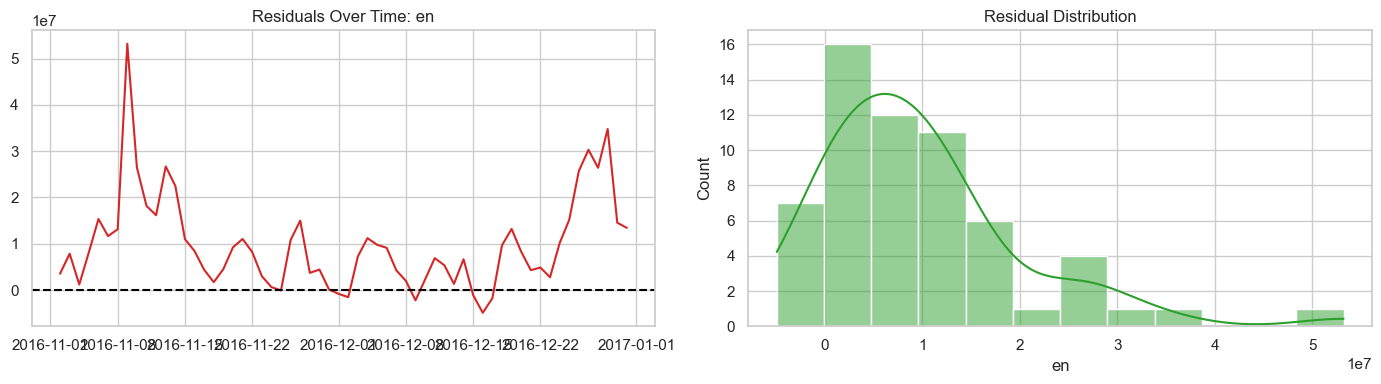

Ljung-Box test on residuals:


,lb_stat,lb_pvalue
7,46.792705,6.126515e-08
14,50.597005,4.848805e-06


In [18]:
# Residual diagnostics for the highest-volume language using its best model
diag_lang = top_languages[0] if top_languages else winner_table.iloc[0]['language']
chosen_row = winner_table[winner_table['language'] == diag_lang].iloc[0]
chosen_model_name = chosen_row['model']

series = ensure_daily_freq(lang_daily[diag_lang])
train, val, test = ts_split(series, val_size=60, test_size=60)
train_val = ensure_daily_freq(pd.concat([train, val]))

if chosen_model_name in ['ARIMA_tuned', 'SARIMA_weekly', 'SARIMAX_weekly_exog']:
    if chosen_model_name == 'ARIMA_tuned':
        best_order = tuple(model_results[(model_results['language'] == diag_lang) & (model_results['model'] == 'ARIMA_tuned')].iloc[0]['order'])
        final_model = SARIMAX(train_val, order=best_order, seasonal_order=(0, 0, 0, 0),
                             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        pred_test = final_model.forecast(steps=len(test))
    else:
        use_exog = (chosen_model_name == 'SARIMAX_weekly_exog') and (campaign_series is not None) and (diag_lang == 'en')
        exog_train_val = campaign_series.loc[train_val.index] if use_exog else None
        exog_test = campaign_series.loc[test.index] if use_exog else None
        final_model = SARIMAX(
            train_val, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7), exog=exog_train_val,
            enforce_stationarity=False, enforce_invertibility=False
        ).fit(disp=False)
        pred_test = final_model.forecast(steps=len(test), exog=exog_test)

    residuals = test - pred_test.values

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(test.index, residuals, color='#d62728')
    axes[0].axhline(0, linestyle='--', color='black')
    axes[0].set_title(f'Residuals Over Time: {diag_lang}')

    sns.histplot(residuals, kde=True, ax=axes[1], color='#2ca02c')
    axes[1].set_title('Residual Distribution')

    plt.tight_layout()
    plt.show()

    lb = acorr_ljungbox(residuals, lags=[7, 14], return_df=True)
    print('Ljung-Box test on residuals:')
    display(lb)
else:
    print(f'Residual diagnostics for model {chosen_model_name} are not implemented in this cell.')

,date,language,forecast_views,model
0,2017-01-01,en,9.299734e+07,ARIMA_tuned
1,2017-01-02,en,9.379401e+07,ARIMA_tuned
2,2017-01-03,en,9.415381e+07,ARIMA_tuned
3,2017-01-04,en,9.431631e+07,ARIMA_tuned
4,2017-01-05,en,9.438969e+07,ARIMA_tuned
5,2017-01-06,en,9.442284e+07,ARIMA_tuned
6,2017-01-07,en,9.443781e+07,ARIMA_tuned
7,2017-01-08,en,9.444457e+07,ARIMA_tuned
8,2017-01-09,en,9.444762e+07,ARIMA_tuned
9,2017-01-10,en,9.444900e+07,ARIMA_tuned


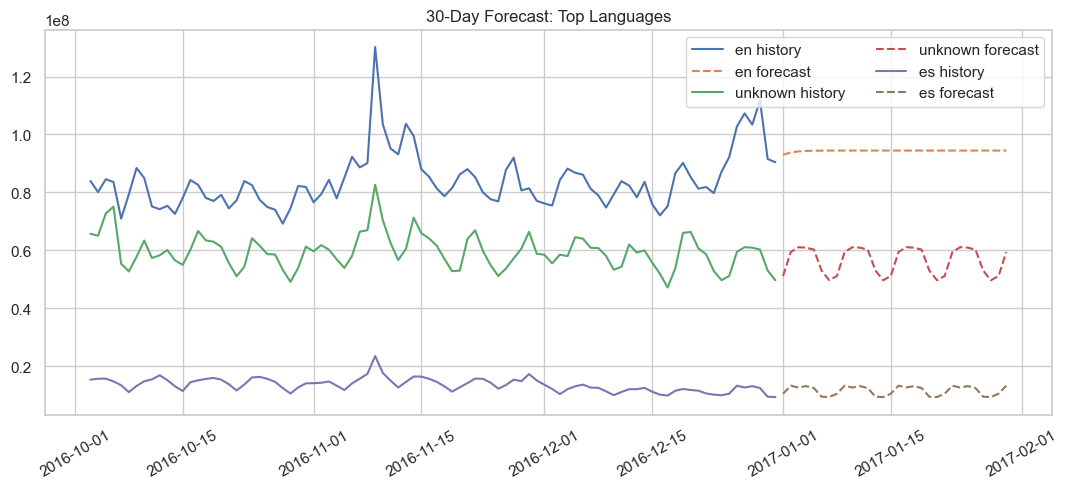

In [19]:
# 30-day forward forecast for top 3 languages using winner model family
forecast_horizon = 30
forecast_rows = []

for lang in top_languages[:3]:
    row = winner_table[winner_table['language'] == lang]
    if row.empty:
        continue

    best_model = row.iloc[0]['model']
    s = ensure_daily_freq(lang_daily[lang].astype(float))

    future_index = pd.date_range(start=s.index.max() + pd.Timedelta(days=1), periods=forecast_horizon, freq='D')

    if best_model == 'SeasonalNaive_7':
        preds = seasonal_naive_forecast(s, forecast_horizon, season_len=7)
    elif best_model == 'Naive':
        preds = naive_forecast(s, forecast_horizon)
    elif best_model == 'MovingAverage_7':
        preds = moving_average_forecast(s, forecast_horizon, window=7)
    elif best_model == 'ARIMA_tuned':
        order_raw = model_results[(model_results['language'] == lang) & (model_results['model'] == 'ARIMA_tuned')].iloc[0]['order']
        order = tuple(order_raw) if not isinstance(order_raw, tuple) else order_raw
        fit = SARIMAX(s, order=order, seasonal_order=(0, 0, 0, 0),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        preds = fit.forecast(steps=forecast_horizon).values
    elif best_model in ['SARIMA_weekly', 'SARIMAX_weekly_exog']:
        use_exog = (best_model == 'SARIMAX_weekly_exog') and (campaign_series is not None) and (lang == 'en')
        exog_all = campaign_series.loc[s.index] if use_exog else None
        fit = SARIMAX(s, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7), exog=exog_all,
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        if use_exog:
            future_exog = np.zeros(forecast_horizon)
            preds = fit.forecast(steps=forecast_horizon, exog=future_exog).values
        else:
            preds = fit.forecast(steps=forecast_horizon).values
    else:
        continue

    for d, p in zip(future_index, preds):
        forecast_rows.append({'date': d, 'language': lang, 'forecast_views': max(0.0, float(p)), 'model': best_model})

forecast_df = pd.DataFrame(forecast_rows)
display(forecast_df.head(15))

plt.figure(figsize=(13, 5))
for lang in forecast_df['language'].unique():
    recent = lang_daily[lang].tail(90)
    fut = forecast_df[forecast_df['language'] == lang]
    plt.plot(recent.index, recent.values, label=f'{lang} history')
    plt.plot(fut['date'], fut['forecast_views'], linestyle='--', label=f'{lang} forecast')

plt.title('30-Day Forecast: Top Languages')
plt.legend(ncol=2)
plt.xticks(rotation=30)
plt.show()

## Interpretation Narrative (From EDA to Modeling Decisions)

The analysis confirms a strongly uneven language demand mix, with English and a high-volume unknown-language bucket dominating total traffic. This concentration implies that forecasting quality improvements in top languages can materially impact ad-allocation efficiency.

Weekly seasonality appears consistently across major languages, and decomposition isolates this recurring signal clearly from trend movement. This directly supports including seasonal structures with period 7 in production-oriented forecasting models.

Outlier diagnostics show periodic spike risk in several languages, especially where event shocks are common. For operations, this means model performance should be monitored with rolling error thresholds and not judged by a single static metric snapshot.

From a stationarity perspective, first differencing and weekly differencing materially improve stability for the focus series. That validates the decision to benchmark differenced ARIMA-family models against simpler naive baselines before selecting deployment candidates.

Model-family guidance for scale: use seasonal-naive as a strong fallback baseline, and promote language-specific ARIMA/SARIMA variants where they demonstrate repeatable validation and holdout gains.

## Executive Summary for Stakeholders
Built an end-to-end multi-language page-view forecasting solution for Ad Ease using 550 daily observations per page across Wikipedia traffic. The workflow covered data reliability checks, metadata extraction, language-level aggregation, stationarity diagnostics, decomposition, and leakage-safe chronological validation.

Baseline models (naive, seasonal naive, moving average) were benchmarked against tuned ARIMA and seasonal SARIMA/SARIMAX variants. Results show that weekly seasonal models generally outperform static baselines, with strongest gains in high-volume languages where recurring weekly demand patterns are pronounced.

Business impact: this forecasting layer enables better ad inventory planning, timing optimization, and language-specific allocation strategies. It also supports proactive interventions for event-driven volatility by monitoring forecast errors and refreshing models on a regular cadence.

## Recommendations, Trade-offs, Risks, Assumptions, and Monitoring Plan

### Actionable recommendations
1. Use language-specific weekly seasonal models as the default production baseline.
2. Prioritize monitoring for high-volume languages because absolute error impact is highest there.
3. Integrate campaign/event calendars consistently (starting with English and expanding to other languages).
4. Retrain on a rolling schedule (for example weekly or biweekly) with drift checks.

### Trade-offs
- Simpler models are easier to maintain but may underperform on event-heavy languages.
- Heavier tuning improves fit but increases operational complexity and compute cost.
- Exogenous variables can improve forecasts but require reliable upstream data pipelines.

### Key assumptions
- Historical behavior is partially representative of near-future behavior.
- Weekly seasonality remains stable enough to be modeled with period 7.
- Traffic anomalies are not permanently structural unless repeated over time.

### Risks
- Sudden external events can break historical patterns and increase forecast error.
- Missing or delayed exogenous campaign signals can degrade model performance.
- Data quality drifts in page naming conventions may affect language extraction.

### Monitoring plan
- Track MAE, RMSE, and sMAPE by language daily.
- Use alert thresholds for error spikes relative to trailing 30-day baseline.
- Run monthly backtesting with the same split policy and compare model rankings.
- Revisit feature set and model family if persistent degradation exceeds thresholds.

## Final Results Dashboard (Submission-Ready)

This section provides a compact business dashboard with only top KPIs and one model recommendation table. It is designed for quick export and stakeholder review.

In [20]:
# Compact KPI dashboard + single recommendation table for export
from IPython.display import Markdown, display

total_languages = int(winner_table['language'].nunique())
best_avg_rmse = float(winner_table['test_RMSE'].mean())
best_avg_smape = float(winner_table['test_sMAPE'].mean())
top_traffic_language = str(language_volume.iloc[0]['language'])
top_traffic_views = float(language_volume.iloc[0]['views'])

model_mix = winner_table['model'].value_counts()
top_model_family = model_mix.index[0]
top_model_family_count = int(model_mix.iloc[0])

display(Markdown(
    f"### KPI Snapshot\n"
    f"- Languages modeled: **{total_languages}**\n"
    f"- Average test RMSE (winner models): **{best_avg_rmse:,.0f}**\n"
    f"- Average test sMAPE (winner models): **{best_avg_smape:.2f}%**\n"
    f"- Highest traffic language: **{top_traffic_language}** with **{top_traffic_views:,.0f}** cumulative views\n"
    f"- Most selected model family: **{top_model_family}** ({top_model_family_count}/{total_languages} languages)"
))

recommendation_table = winner_table[
    ['language', 'model', 'test_MAE', 'test_RMSE', 'test_R2', 'test_sMAPE']
].copy()

recommendation_table = recommendation_table.rename(columns={
    'language': 'Language',
    'model': 'Recommended Model',
    'test_MAE': 'Test MAE',
    'test_RMSE': 'Test RMSE',
    'test_R2': 'Test R2',
    'test_sMAPE': 'Test sMAPE (%)'
}).sort_values('Test RMSE')

display(Markdown('### Final Model Recommendation Table'))
display(recommendation_table)

export_path = Path('final_model_recommendation_table.csv')
recommendation_table.to_csv(export_path, index=False)
print(f'Recommendation table exported to: {export_path.resolve()}')

### KPI Snapshot
- Languages modeled: **8**
- Average test RMSE (winner models): **3,501,125**
- Average test sMAPE (winner models): **8.89%**
- Highest traffic language: **en** with **41,439,700,878** cumulative views
- Most selected model family: **SeasonalNaive_7** (4/8 languages)

### Final Model Recommendation Table

,Language,Recommended Model,Test MAE,Test RMSE,Test R2,Test sMAPE (%)
7,zh,SeasonalNaive_7,2.293596e+05,3.680245e+05,0.345988,4.930013
3,fr,SARIMA_weekly,6.868643e+05,1.048907e+06,0.133826,6.963683
5,ru,Naive,9.394439e+05,1.363121e+06,-0.666671,8.776396
4,ja,SeasonalNaive_7,1.147866e+06,1.643666e+06,0.079573,8.754628
0,de,Naive,1.503639e+06,1.905302e+06,-0.083437,11.078940
2,es,SeasonalNaive_7,1.677730e+06,2.154497e+06,0.239638,12.422111
6,unknown,SeasonalNaive_7,3.762603e+06,5.340490e+06,0.228833,6.324407
1,en,ARIMA_tuned,1.021441e+07,1.418499e+07,-0.907278,11.843813


Recommendation table exported to: C:\Users\prath\Desktop\Prathamesh\Prathamesh\Learn\DSML\12 ML2 Unsupervised and RecSys\TimeSeries\analysis_1\final_model_recommendation_table.csv
